In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt

# 1. Dataset Preparation
transform = transforms.ToTensor() # Converts to [0, 1] range for Bernoulli output
mnist_train = datasets.MNIST(root='../data', train=True, download=True, transform=transform)
mnist_test = datasets.MNIST(root='../data', train=False, download=True, transform=transform)

train_loader = DataLoader(mnist_train, batch_size=128, shuffle=True)
test_loader = DataLoader(mnist_test, batch_size=128, shuffle=False)

# 2. VAE Architecture
class VAE(nn.Module):
    def __init__(self, latent_dim=2):
        super(VAE, self).__init__()
        # Encoder
        self.fc1 = nn.Linear(784, 400)
        self.fc2_mu = nn.Linear(400, latent_dim)
        self.fc2_logvar = nn.Linear(400, latent_dim)
        
        # Decoder
        self.fc3 = nn.Linear(latent_dim, 400)
        self.fc4 = nn.Linear(400, 784)

    def encode(self, x):
        h1 = F.relu(self.fc1(x))
        return self.fc2_mu(h1), self.fc2_logvar(h1)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h3 = F.relu(self.fc3(z))
        # Sigmoid activation to output probabilities for the BCE loss
        return torch.sigmoid(self.fc4(h3))

    def forward(self, x):
        # Flatten the 28x28 image to a 784 vector
        mu, logvar = self.encode(x.view(-1, 784))
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

# 3. ELBO Loss Function
def vae_loss_function(recon_x, x, mu, logvar):
    # Reconstruction loss: Binary Cross Entropy
    BCE = F.binary_cross_entropy(recon_x, x.view(-1, 784), reduction='sum')
    # KL Divergence
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD

# 4. Training Loop Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = VAE(latent_dim=2).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
epochs = 15

# 5. Execute Training
model.train()
for epoch in range(1, epochs + 1):
    train_loss = 0
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch}/{epochs}")
    for batch_idx, (data, _) in enumerate(progress_bar):
        data = data.to(device)
        optimizer.zero_grad()
        
        recon_batch, mu, logvar = model(data)
        loss = vae_loss_function(recon_batch, data, mu, logvar)
        
        loss.backward()
        train_loss += loss.item()
        optimizer.step()
        
        progress_bar.set_postfix({'Loss': loss.item() / len(data)})
        
    avg_loss = train_loss / len(train_loader.dataset)
    print(f'====> Epoch: {epoch} Average Loss (ELBO): {avg_loss:.4f}')

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:02<00:00, 3.73MB/s]


Extracting ../data\MNIST\raw\train-images-idx3-ubyte.gz to ../data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 122kB/s]


Extracting ../data\MNIST\raw\train-labels-idx1-ubyte.gz to ../data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



...

====> Epoch: 13 Average Loss (ELBO): 152.4165


Epoch 14/15: 100%|██████████| 469/469 [00:06<00:00, 67.69it/s, Loss=152]


====> Epoch: 14 Average Loss (ELBO): 151.9793


Epoch 15/15: 100%|██████████| 469/469 [00:06<00:00, 68.14it/s, Loss=153]

====> Epoch: 15 Average Loss (ELBO): 151.5377


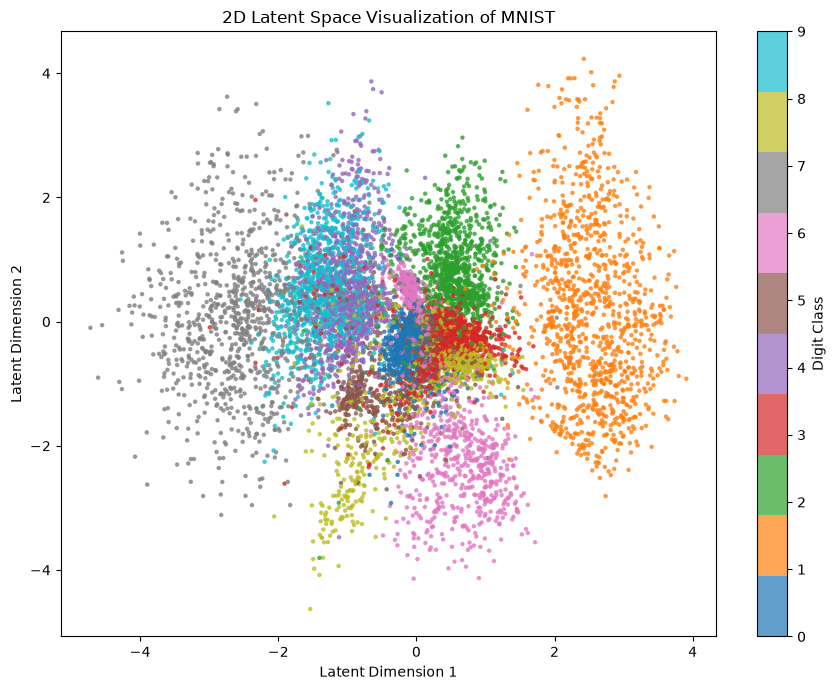

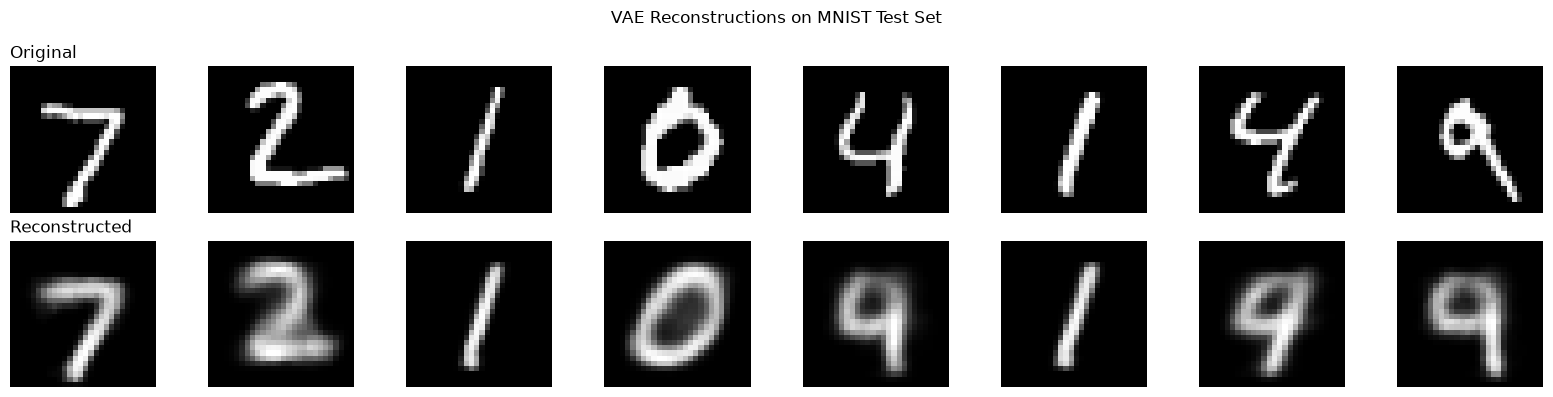

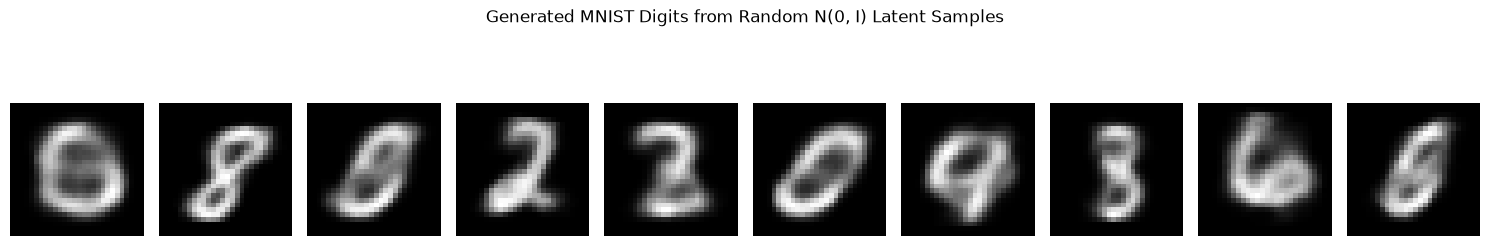

In [2]:
import numpy as np

model.eval()

# --- Task 4.2(a): Latent Space Visualization ---
all_mu = []
all_labels = []
with torch.no_grad():
    for data, labels in test_loader:
        data = data.to(device)
        mu, logvar = model.encode(data.view(-1, 784))
        all_mu.append(mu.cpu())
        all_labels.append(labels)

all_mu = torch.cat(all_mu, dim=0).numpy()
all_labels = torch.cat(all_labels, dim=0).numpy()

plt.figure(figsize=(9, 7))
scatter = plt.scatter(all_mu[:, 0], all_mu[:, 1], c=all_labels, cmap='tab10', alpha=0.7, s=5)
plt.colorbar(scatter, label='Digit Class')
plt.title('2D Latent Space Visualization of MNIST')
plt.xlabel('Latent Dimension 1')
plt.ylabel('Latent Dimension 2')
plt.tight_layout()
plt.savefig('../report/figures/task4_latent_space.png', dpi=300)
plt.show()

# --- Task 4.2(b): Reconstruction Quality ---
data, _ = next(iter(test_loader))
data = data.to(device)
with torch.no_grad():
    recon_batch, _, _ = model(data)

n = 8
plt.figure(figsize=(16, 4))
for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(data[i].cpu().view(28, 28).numpy(), cmap='gray')
    ax.axis('off')
    if i == 0: ax.set_title('Original', loc='left')

    # Reconstruction
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(recon_batch[i].cpu().view(28, 28).numpy(), cmap='gray')
    ax.axis('off')
    if i == 0: ax.set_title('Reconstructed', loc='left')

plt.suptitle('VAE Reconstructions on MNIST Test Set')
plt.tight_layout()
plt.savefig('../report/figures/task4_reconstructions.png', dpi=300)
plt.show()

# --- Task 4.2(c): Generation of New Samples ---
with torch.no_grad():
    # Sample 10 random points from standard normal distribution
    z = torch.randn(10, 2).to(device)
    generated = model.decode(z).cpu().view(-1, 28, 28)

plt.figure(figsize=(15, 3))
for i in range(10):
    ax = plt.subplot(1, 10, i + 1)
    plt.imshow(generated[i].numpy(), cmap='gray')
    ax.axis('off')

plt.suptitle('Generated MNIST Digits from Random N(0, I) Latent Samples')
plt.tight_layout()
plt.savefig('../report/figures/task4_generations.png', dpi=300)
plt.show()